In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Colab \Notebooks/microscopy_self_supervised_learning/

/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning


Imports & setup

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from skimage.io import imread
from skimage.transform import resize
import cv2

Paths & metadata

In [10]:
metadata = pd.read_csv("data/processed/1metadata_with_moa.csv")
metadata.tail(3)

,TableNumber,ImageNumber,Image_FileName_DAPI,Image_PathName_DAPI,Image_FileName_Tubulin,Image_PathName_Tubulin,Image_FileName_Actin,Image_PathName_Actin,plate,well,Replicate,compound,concentration,moa
761,2,3118,Week2_180607_G11_s2_w165B32396-0153-460A-B15C-...,Week2/Week2_24361,Week2_180607_G11_s2_w2379BF64A-3E06-4B5C-9379-...,Week2/Week2_24361,Week2_180607_G11_s2_w47F52899B-77FC-4304-AD31-...,Week2/Week2_24361,Week2_24361,G11,1,DMSO,0.0,DMSO
762,2,3119,Week2_180607_G11_s3_w1851DF27B-FD44-4A8D-853A-...,Week2/Week2_24361,Week2_180607_G11_s3_w247482A9E-99E7-4D14-9D9B-...,Week2/Week2_24361,Week2_180607_G11_s3_w4E158F1C2-14ED-4FFF-B6D1-...,Week2/Week2_24361,Week2_24361,G11,1,DMSO,0.0,DMSO
763,2,3120,Week2_180607_G11_s4_w16E388AEC-DC66-4BF3-85E8-...,Week2/Week2_24361,Week2_180607_G11_s4_w24E6FDA1D-CA28-4436-BD07-...,Week2/Week2_24361,Week2_180607_G11_s4_w4C7F07804-4C38-4202-BA26-...,Week2/Week2_24361,Week2_24361,G11,1,DMSO,0.0,DMSO


In [5]:
DATA_DIR = "data/raw"
RESULTS_DIR = "results/figures"

In [6]:
metadata['Image_FileName_DAPI'][0]

'Week1_150607_B04_s3_w135D66B4C-0548-4AB8-A57B-9CC39666813B.tif'

Image loader function

In [7]:
import os
import tifffile as tiff
import numpy as np

BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning/data/raw"

def fix_path(pathname):
    return pathname.split("/")[-1]

helper fucntion to deal with 4 missing images

In [8]:
def image_exists(row):
    paths = [
        os.path.join(BASE_DIR, fix_path(row["Image_PathName_DAPI"]), row["Image_FileName_DAPI"]),
        os.path.join(BASE_DIR, fix_path(row["Image_PathName_Tubulin"]), row["Image_FileName_Tubulin"]),
        os.path.join(BASE_DIR, fix_path(row["Image_PathName_Actin"]), row["Image_FileName_Actin"])
    ]

    return all(os.path.exists(p) for p in paths)

In [9]:
metadata_clean = metadata[metadata.apply(image_exists, axis=1)].reset_index(drop=True)

print("Original rows:", len(metadata))
print("Valid rows:", len(metadata_clean))
print("Removed rows:", len(metadata) - len(metadata_clean))

Original rows: 764
Valid rows: 0
Removed rows: 764


In [13]:

def load_3channel_image(row):
    paths = [
        os.path.join(BASE_DIR, fix_path(row["Image_PathName_DAPI"]), row["Image_FileName_DAPI"]),
        os.path.join(BASE_DIR, fix_path(row["Image_PathName_Tubulin"]), row["Image_FileName_Tubulin"]),
        os.path.join(BASE_DIR, fix_path(row["Image_PathName_Actin"]), row["Image_FileName_Actin"])
    ]

    channels = []
    for p in paths:
        img = tiff.imread(p).astype(np.float32)
        # normalize
        img = img / 65535.0

        channels.append(img)

    img_stack = np.stack(channels, axis=0)   # (3, H, W)
    return img_stack

Dataset class

In [ ]:
from skimage.transform import resize
import torch

class MicroscopyDataset(Dataset):
    def __init__(self, metadata_df, img_size=128):
        self.meta = metadata_df.reset_index(drop=True) #dataframe might have non-sequential indices after filtering
        self.img_size = img_size

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        img = load_3channel_image(row)   # (3,1024,1280)

        # resize to (3,128,128)
        img = resize(img, (3, self.img_size, self.img_size), anti_aliasing=True) #Anti-aliasing applies a smoothing filter before resizing

        img = torch.tensor(img, dtype=torch.float32)
        label = row["moa"]
        return img, label

In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning/data/raw/Week1_22123/Week1_150607_B04_s3_w135D66B4C-0548-4AB8-A57B-9CC39666813B.tif'
img = tiff.imread(path)

print(img.shape)
print(img.dtype)
print(img.min(), img.max())

(1024, 1280)
uint16
208 7488


#sanity checks

In [12]:
#is resizing happening properly?
row = metadata.iloc[0]

img = load_3channel_image(row)

print("Before resize:", img.shape)

img_resized = resize(img, (3,128,128), anti_aliasing=True)

print("After resize:", img_resized.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning/data/raw/Week1_22123/Week1_150607_B04_s3_w135D66B4C-0548-4AB8-A57B-9CC39666813B.tif'

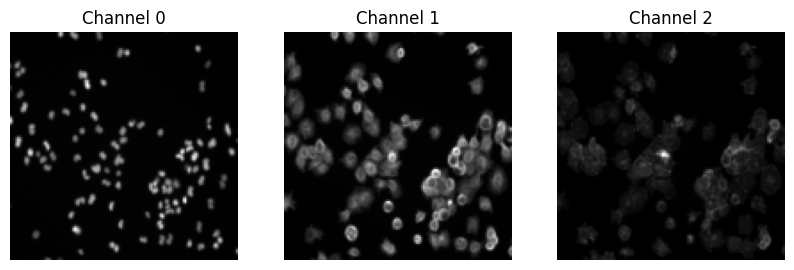

In [ ]:
#are channels mixing?
import matplotlib.pyplot as plt

img = load_3channel_image(metadata.iloc[0])

img = resize(img, (3,128,128))

plt.figure(figsize=(10,3))

for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(img[i], cmap="gray")
    plt.title(f"Channel {i}")
    plt.axis("off")

plt.show()

In [ ]:
#pixel range
print(img.min(), img.max())

0.0073711816 0.5254013


DataLoader

In [ ]:
dataset = MicroscopyDataset(metadata_clean, img_size=128)
x, y = dataset[0]
print(x.shape)

torch.Size([3, 128, 128])


In [ ]:
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, drop_last=True)

Autoencoder model

In [ ]:
import torch
import torch.nn as nn

class Autoencoder(nn.Module):

    def __init__(self, latent_dim=512):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3,16,3,stride=2,padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Conv2d(16,32,3,stride=2,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32,64,3,stride=2,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Flatten(),
            nn.Linear(64*16*16, latent_dim)
        )

        # Decoder
        self.decoder_fc = nn.Linear(latent_dim, 64*16*16)

        self.decoder = nn.Sequential(

            # 16x16 → 32x32
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # 32x32 → 64x64
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(32,16,3,padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            # 64x64 → 128x128
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(16,3,3,padding=1),
            nn.Sigmoid()
        )

    def forward(self,x):

        z = self.encoder(x)

        x = self.decoder_fc(z)
        x = x.view(-1,64,16,16)

        out = self.decoder(x)

        return out, z

In [ ]:
import torch
import torch.nn as nn

class StrongAutoencoder(nn.Module):

    def __init__(self, latent_dim=256):
        super().__init__()

        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = nn.Sequential(
            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.pool3 = nn.MaxPool2d(2)

        self.flatten = nn.Flatten()
        self.fc = nn.Linear(128*16*16, latent_dim)

        self.fc_dec = nn.Linear(latent_dim,128*16*16)

        # Decoder

        self.up1 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)
        self.dec1 = nn.Sequential(
            nn.Conv2d(128,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.up2 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)
        self.dec2 = nn.Sequential(
            nn.Conv2d(64,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        self.up3 = nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False)
        self.dec3 = nn.Sequential(
            nn.Conv2d(32,3,3,padding=1),
            nn.Sigmoid()
        )

    def forward(self,x):

        x = self.enc1(x)
        x = self.pool1(x)

        x = self.enc2(x)
        x = self.pool2(x)

        x = self.enc3(x)
        x = self.pool3(x)

        z = self.fc(self.flatten(x))

        x = self.fc_dec(z)
        x = x.view(-1,128,16,16)

        x = self.up1(x)
        x = self.dec1(x)

        x = self.up2(x)
        x = self.dec2(x)

        x = self.up3(x)
        out = self.dec3(x)

        return out, z

sanity check

In [ ]:
model = Autoencoder()

x, y = dataset[0]
x = x.unsqueeze(0)   # add batch dimension

recon, z = model(x)

print("Input shape:", x.shape)
print("Reconstruction shape:", recon.shape)
print("Latent shape:", z.shape)

Input shape: torch.Size([1, 3, 128, 128])
Reconstruction shape: torch.Size([1, 3, 128, 128])
Latent shape: torch.Size([1, 512])


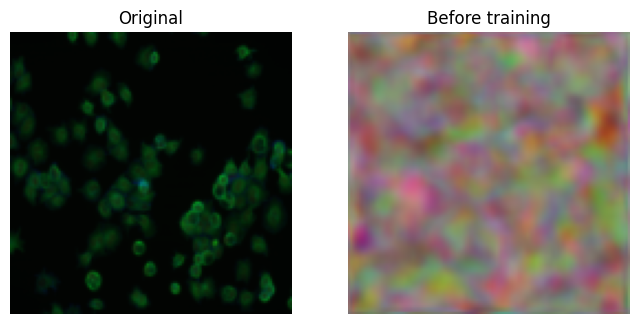

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(x[0].permute(1,2,0))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(recon[0].detach().permute(1,2,0))
plt.title("Before training")
plt.axis("off")

plt.show()

Train setup

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
model = Autoencoder(latent_dim=512)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 150

Training loop

In [ ]:
x, y = dataset[0]
print(x.shape)   # must be torch.Size([3,128,128])

torch.Size([3, 128, 128])


#saniy check

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model.to(device)

single_img = x.unsqueeze(0).to(device)

for i in range(500):

    recon, _ = model(single_img)
    loss = criterion(recon, single_img)

    optimizer.zero_grad()
    loss.backward()
    for name, param in model.named_parameters():
      if param.grad is not None:
          print(name, param.grad.abs().mean().item())
          break
    optimizer.step()

    if i % 100 == 0:
        print(i, loss.item())

enc1.0.weight 0.00034845274058170617
0 0.4634348452091217
enc1.0.weight 6.164828846522141e-06
enc1.0.weight 2.149297870346345e-06
enc1.0.weight 5.943485348325339e-07
enc1.0.weight 3.649007851436181e-07
enc1.0.weight 2.2058513593492535e-07
enc1.0.weight 2.0139049183853786e-07
enc1.0.weight 1.668800138077131e-07
enc1.0.weight 1.4281474136623729e-07
enc1.0.weight 1.2343031130512827e-07
enc1.0.weight 9.278445389782064e-08
enc1.0.weight 8.507510074196034e-08
enc1.0.weight 8.164963105627976e-08
enc1.0.weight 7.382697475577515e-08
enc1.0.weight 6.311969258376848e-08
enc1.0.weight 3.6572853190364185e-08
enc1.0.weight 7.651269129382854e-08
enc1.0.weight 7.226788767411563e-08
enc1.0.weight 6.375837813266116e-08
enc1.0.weight 4.576529732958079e-08
enc1.0.weight 1.9444282628455767e-08
enc1.0.weight 1.9002323270456145e-08
enc1.0.weight 3.8013247660728666e-08
enc1.0.weight 6.245430483886594e-08
enc1.0.weight 3.034475071217457e-08
enc1.0.weight 2.331559123547322e-08
enc1.0.weight 4.5880433674483356e-

In [ ]:
print("latent mean:", z.mean().item())
print("latent std:", z.std().item())

latent mean: 0.12581858038902283
latent std: 0.6920136213302612


In [ ]:
import matplotlib.pyplot as plt
import torch

def visualize_reconstruction(model, dataset, device="cpu"):

    model.eval()

    img, label = dataset[0]              # get one sample
    img = img.unsqueeze(0).to(device)   # add batch dimension

    with torch.no_grad():
        recon, _ = model(img)

    img = img.squeeze().cpu()
    recon = recon.squeeze().cpu()

    # compute absolute error
    error = torch.abs(img - recon)

    fig, axes = plt.subplots(3, 3, figsize=(9,9))

    channel_names = ["DAPI", "Tubulin", "Actin"]

    for c in range(3):

        # Original
        axes[0,c].imshow(img[c], cmap="gray")
        axes[0,c].set_title(f"Original {channel_names[c]}")
        axes[0,c].axis("off")

        # Reconstruction
        axes[1,c].imshow(recon[c], cmap="gray")
        axes[1,c].set_title("Reconstructed")
        axes[1,c].axis("off")

        # Error
        axes[2,c].imshow(error[c], cmap="hot")
        axes[2,c].set_title("Error")
        axes[2,c].axis("off")

    plt.tight_layout()
    plt.show()

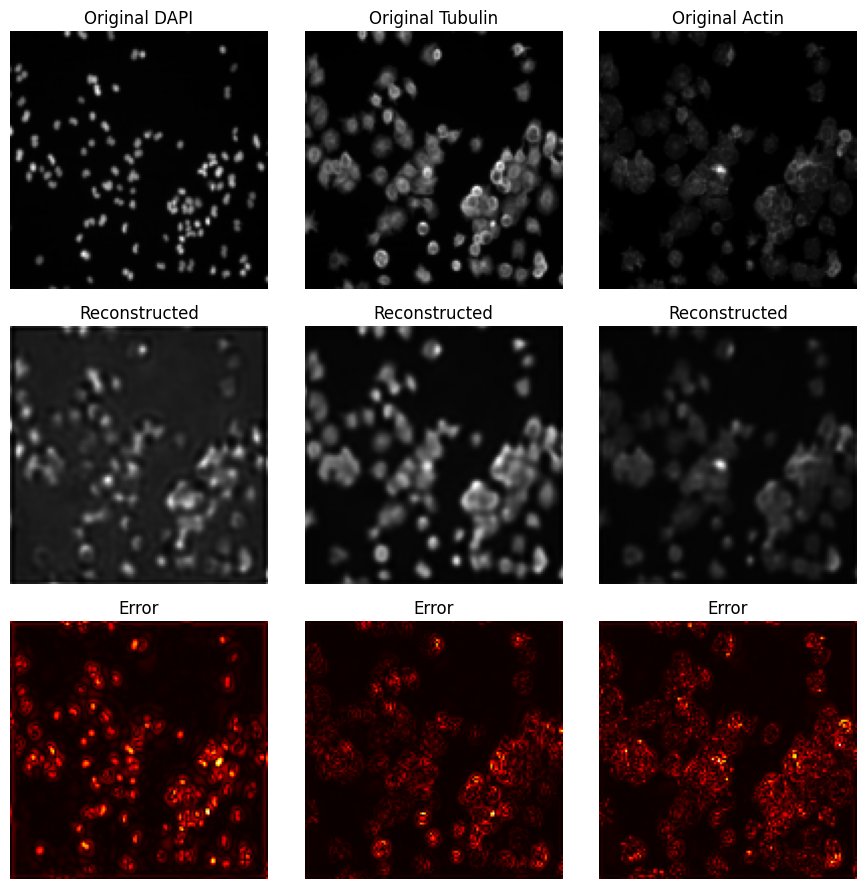

In [ ]:
visualize_reconstruction(model, dataset)

In [ ]:
print("Input min:", img.min().item())
print("Input max:", img.max().item())

print("Recon min:", recon.min().item())
print("Recon max:", recon.max().item())

Input min: 0.00737118162214756
Input max: 0.5254012942314148
Recon min: 0.124797523021698
Recon max: 0.695483386516571


Train

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
train_losses = []

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0

    loop = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for imgs, labels in loop:

        imgs = imgs.float().to(device)

        recon, embedding = model(imgs)

        loss = criterion(recon, imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        loop.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(dataloader)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1} Loss: {epoch_loss:.4f}")

Epoch 1/150: 100%|██████████| 16/16 [19:15<00:00, 72.22s/it, loss=0.269]


Epoch 1 Loss: 0.3634


Epoch 2/150: 100%|██████████| 16/16 [02:58<00:00, 11.18s/it, loss=0.108]


Epoch 2 Loss: 0.1776


Epoch 3/150: 100%|██████████| 16/16 [02:43<00:00, 10.23s/it, loss=0.0425]


...

Epoch 124/150: 100%|██████████| 16/16 [02:36<00:00,  9.78s/it, loss=0.00841]


Epoch 124 Loss: 0.0084


Epoch 125/150: 100%|██████████| 16/16 [02:36<00:00,  9.76s/it, loss=0.00851]


Epoch 125 Loss: 0.0082


Epoch 126/150:  12%|█▎        | 2/16 [00:18<02:11,  9.36s/it, loss=0.00828]

In [ ]:
print(recon.min(), recon.max())

Plot training loss

In [ ]:
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training Loss")
plt.savefig(f"{RESULTS_DIR}/autoencoder_loss.png")
plt.show()

Reconstruction visualization

In [ ]:
fig, axes = plt.subplots(2,6, figsize=(12,4))

for i in range(6):

    axes[0,i].imshow(input_examples[i].permute(1,2,0))
    axes[0,i].axis("off")


    axes[1,i].imshow(recon_examples[i].permute(1,2,0))
    axes[1,i].axis("off")

axes[0,0].set_title("Original")
axes[1,0].set_title("Reconstructed")
plt.savefig(f"{RESULTS_DIR}/autoencoder_original_reconstructions.png")
plt.show()

In [ ]:
model.eval()
imgs, labels = next(iter(dataloader))
imgs = imgs.to(device)

with torch.no_grad():
    recon, z = model(imgs)

imgs = imgs.cpu().numpy()
recon = recon.cpu().numpy()

fig, axes = plt.subplots(3, 6, figsize=(12, 6))

for i in range(6):
    orig = imgs[i,0]
    rec  = recon[i,0]
    err  = np.abs(orig - rec)

    axes[0,i].imshow(orig, cmap="gray", vmin=0, vmax=1)
    axes[1,i].imshow(rec,  cmap="gray", vmin=0, vmax=1)
    axes[2,i].imshow(err,  cmap="hot")

    for j in range(3):
        axes[j,i].axis("off")

plt.suptitle("Top: Original | Middle: Reconstructed | Bottom: Error")
plt.savefig(f"{RESULTS_DIR}/autoencoder_original_reconstruction_error.png")
plt.show()

Flatten in encoder is problem Main problem: Flattening destroys spatial structure

Second problem: Huge compression immediately

Your first layer compresses:

49,152 features → 256

That is a 192× compression in one step.

Then you compress again:

256 → 128

So the encoder forces the entire image into 128 numbers almost instantly.

That is extremely aggressive and makes training unstable.

Second problem: Huge compression immediately

Your first layer compresses:

49,152 features → 256

That is a 192× compression in one step.

Then you compress again:

256 → 128

So the encoder forces the entire image into 128 numbers almost instantly.

That is extremely aggressive and makes training unstable.

In [ ]:
print(imgs.min(), imgs.max())

fixed : normalisation

Middle row (reconstruction):
❌ Looks like random noise / static
❌ No cell structure recovered
❌ Almost constant texture across images

→ confirms the model is not reconstructing meaningful signal.

Extract embeddings

In [ ]:
embeddings = []
labels = []

model.eval()

for _, row in tqdm(metadata_clean.iterrows(), total=len(metadata_clean)):

    img = load_3channel_image(row)  # (3,1024,1280)

    img_small = resize(img, (3,128,128), anti_aliasing=True)

    x = torch.tensor(img_small, dtype=torch.float32)
    x = x.unsqueeze(0).to(device)
    with torch.no_grad():
        recon, z = model(x)

    embeddings.append(z.cpu().numpy().squeeze())
    labels.append(row["moa"])

Save embeddings

In [ ]:
embeddings = np.array(embeddings)

np.save("data/processed/autoencoder_embeddings.npy", embeddings)
subset[["moa"]].to_csv("data/processed/autoencoder_labels.csv", index=False)

print("Saved embeddings:", embeddings.shape)

UMAP visualization

In [ ]:
from umap import UMAP
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_enc = le.fit_transform(labels)

umap = UMAP(n_components=2, random_state=42)
Z = umap.fit_transform(embeddings)

plt.figure(figsize=(6,5))
plt.scatter(Z[:,0], Z[:,1], c=y_enc, cmap="tab10", s=10)
plt.title("Autoencoder embeddings (UMAP)")
plt.colorbar()
plt.savefig(f"{RESULTS_DIR}/umap_autoencoder_by_moa.png")
plt.show()